<a href="https://colab.research.google.com/github/huanbv/BVU.CaoHoc.BuiVanHuan-TriTueNhanTaoNangCao_UngDung/blob/main/Lab1_Perceptron_DuyetVay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BÀI THỰC HÀNH SỐ 1 – PERCEPTRON MỘT LỚP
## Dự đoán khả năng duyệt hồ sơ vay tiêu dùng

**Sinh viên:** BÙI VĂN  &nbsp;&nbsp; **MSSV:** 26110028 &nbsp;&nbsp;

## Bước 0. Kết nối Google Drive và nạp thư viện

In [1]:
import os
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/ANN_Lab'
except ImportError:
    DATA_DIR = './ANN_Lab'
os.makedirs(DATA_DIR, exist_ok=True)
print('Thư mục dữ liệu:', DATA_DIR)
print('Các file hiện có:', os.listdir(DATA_DIR))

Mounted at /content/drive
Thư mục dữ liệu: /content/drive/MyDrive/ANN_Lab
Các file hiện có: ['lab2_train.csv', 'lab1_train.csv', 'lab1_duyet_vay.csv', 'lab2_sau_rieng.csv', 'lab2_test.csv', 'lab1_test.csv']


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
np.set_printoptions(precision=3, suppress=True)
pd.set_option('display.precision', 3)

## Bước 1. Đọc dữ liệu từ Drive

In [3]:
FILE_ALL = os.path.join(DATA_DIR, 'lab1_duyet_vay.csv')
def make_lab1(seed=2026, n=300):
    rng = np.random.default_rng(seed)
    thu_nhap = np.clip(rng.lognormal(np.log(18), 0.5, n), 5, 80).round(1)
    ty_le_no = np.clip(rng.normal(38, 15, n), 5, 85).round(1)
    diem = np.clip(rng.normal(560, 75, n), 150, 750).round(0).astype(int)
    nam = np.clip(rng.gamma(2, 3, n), 0, 30).round(0).astype(int)
    z = (0.09*(thu_nhap-18) - 0.07*(ty_le_no-38) + 0.026*(diem-560)
         + 0.12*(nam-6) + rng.normal(0, 0.45, n))
    return pd.DataFrame({'ma_ho_so': [f'HS{i:03d}' for i in range(1, n+1)],
                         'thu_nhap': thu_nhap, 'ty_le_no': ty_le_no,
                         'diem_tin_dung': diem, 'so_nam_cong_tac': nam,
                         'duyet_vay': (z > 0).astype(int)})
if not os.path.exists(FILE_ALL):
    make_lab1().to_csv(FILE_ALL, index=False)
    print('Chưa có file, đã sinh dữ liệu và lưu vào', FILE_ALL)
df = pd.read_csv(FILE_ALL)
print('Kích thước:', df.shape)
df.head(10)

Kích thước: (300, 6)


,ma_ho_so,thu_nhap,ty_le_no,diem_tin_dung,so_nam_cong_tac,duyet_vay
0,HS001,12.1,38.7,629,12,1
1,HS002,20.3,22.4,551,4,1
2,HS003,7.0,54.3,614,6,1
3,HS004,36.2,62.0,436,11,0
4,HS005,24.8,39.0,540,3,0
5,HS006,15.6,63.2,579,1,0
6,HS007,15.4,36.3,559,9,1
7,HS008,21.0,11.4,714,4,1
8,HS009,15.7,28.2,583,4,1
9,HS010,16.1,22.1,587,4,1


## Bước 2. Khám phá dữ liệu (EDA)

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ma_ho_so         300 non-null    object 
 1   thu_nhap         300 non-null    float64
 2   ty_le_no         300 non-null    float64
 3   diem_tin_dung    300 non-null    int64  
 4   so_nam_cong_tac  300 non-null    int64  
 5   duyet_vay        300 non-null    int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 14.2+ KB


,thu_nhap,ty_le_no,diem_tin_dung,so_nam_cong_tac,duyet_vay
count,300.000,300.000,300.000,300.000,300.000
mean,21.611,38.060,562.880,5.583,0.580
std,12.541,15.340,75.066,3.815,0.494
min,5.000,5.000,343.000,0.000,0.000
25%,12.900,26.975,513.500,3.000,0.000
50%,18.950,38.500,563.000,5.000,1.000
75%,26.300,48.600,614.000,7.250,1.000
max,80.000,85.000,742.000,22.000,1.000


Số hồ sơ duyệt (1): 174 | từ chối (0): 126


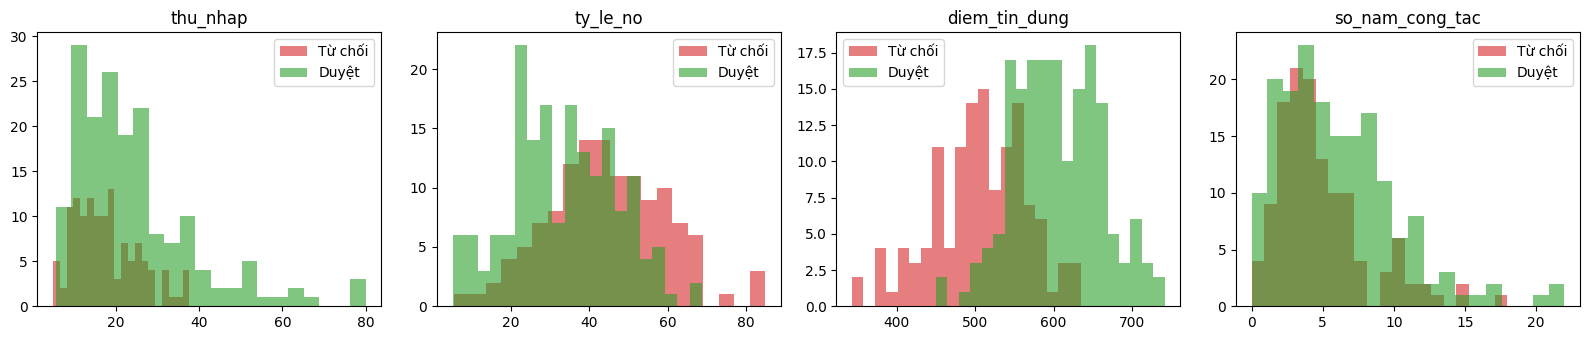

In [5]:
FEATURES = ['thu_nhap', 'ty_le_no', 'diem_tin_dung', 'so_nam_cong_tac']
TARGET = 'duyet_vay'
counts = df[TARGET].value_counts()
print('Số hồ sơ duyệt (1):', counts[1], '| từ chối (0):', counts[0])
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, col in zip(axes, FEATURES):
    for lab, color, name in [(0, 'tab:red', 'Từ chối'), (1, 'tab:green', 'Duyệt')]:
        ax.hist(df.loc[df[TARGET] == lab, col], bins=20, alpha=0.6, color=color, label=name)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

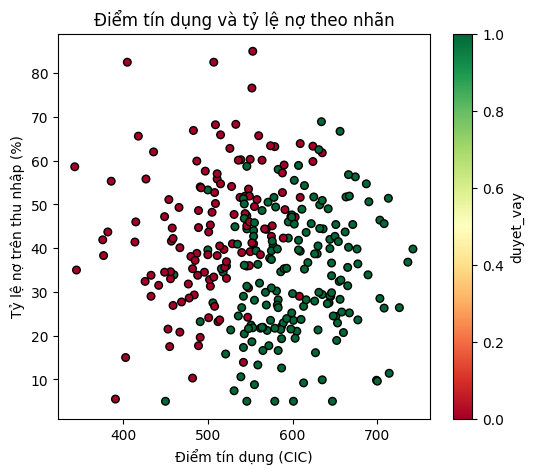

In [6]:
plt.figure(figsize=(6, 5))
sc = plt.scatter(df['diem_tin_dung'], df['ty_le_no'], c=df[TARGET], cmap='RdYlGn', edgecolor='k', s=30)
plt.xlabel('Điểm tín dụng (CIC)')
plt.ylabel('Tỷ lệ nợ trên thu nhập (%)')
plt.title('Điểm tín dụng và tỷ lệ nợ theo nhãn')
plt.colorbar(sc, label='duyet_vay')
plt.show()

In [7]:
# Bổ sung: tương quan của từng thuộc tính với nhãn (để kiểm chứng Câu hỏi 1)
df[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).round(2)

,duyet_vay
thu_nhap,0.26
ty_le_no,-0.36
diem_tin_dung,0.65
so_nam_cong_tac,0.17


### Trả lời Câu hỏi 1
**Thuộc tính tác động ngược chiều:** `ty_le_no` (tỷ lệ nợ trên thu nhập). Trên histogram, các hồ sơ bị từ chối dồn về phía tỷ lệ nợ cao (trung bình 44.5% so với 33.4% ở nhóm được duyệt), hệ số tương quan với nhãn ≈ −0.36. Tỷ lệ nợ càng cao thì phần thu nhập còn lại để trả khoản vay mới càng ít ⇒ rủi ro cao ⇒ dễ bị từ chối.

**Dự đoán dấu trọng số sau huấn luyện:**
- $w_{ty\_le\_no} < 0$ (âm).
- $w_{thu\_nhap}$, $w_{diem\_tin\_dung}$, $w_{so\_nam\_cong\_tac} > 0$ (dương) vì giá trị càng lớn càng dễ được duyệt.
- `diem_tin_dung` tách hai lớp rõ nhất (tương quan +0.65) nên dự đoán trọng số của nó có độ lớn lớn nhất; `so_nam_cong_tac` yếu nhất (+0.17).

## Bước 3. Chia 80% huấn luyện, 20% kiểm thử và lưu lên Drive

In [8]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df[TARGET])
train_df.to_csv(os.path.join(DATA_DIR, 'lab1_train.csv'), index=False)
test_df.to_csv(os.path.join(DATA_DIR, 'lab1_test.csv'), index=False)
print(f'Train: {len(train_df)} hồ sơ | Test: {len(test_df)} hồ sơ')
n_tr = train_df[TARGET].sum()
n_te = test_df[TARGET].sum()
print(f'Tỷ lệ duyệt train = {n_tr}/{len(train_df)} = {n_tr/len(train_df):.3f}')
print(f'Tỷ lệ duyệt test  = {n_te}/{len(test_df)} = {n_te/len(test_df):.3f}')
print(f'Tỷ lệ duyệt toàn bộ = {df[TARGET].sum()}/{len(df)} = {df[TARGET].mean():.3f}')

Train: 240 hồ sơ | Test: 60 hồ sơ
Tỷ lệ duyệt train = 139/240 = 0.579
Tỷ lệ duyệt test  = 35/60 = 0.583
Tỷ lệ duyệt toàn bộ = 174/300 = 0.580


In [9]:
# Bổ sung cho Câu hỏi 2: nếu KHÔNG stratify, tỷ lệ duyệt ở tập test thay đổi theo random_state
for rs in range(8):
    _, te = train_test_split(df, test_size=0.2, random_state=rs)
    print(f'random_state={rs}: tỷ lệ duyệt test = {te[TARGET].mean():.3f}')

random_state=0: tỷ lệ duyệt test = 0.533
random_state=1: tỷ lệ duyệt test = 0.600
random_state=2: tỷ lệ duyệt test = 0.550
random_state=3: tỷ lệ duyệt test = 0.633
random_state=4: tỷ lệ duyệt test = 0.583
random_state=5: tỷ lệ duyệt test = 0.650
random_state=6: tỷ lệ duyệt test = 0.600
random_state=7: tỷ lệ duyệt test = 0.517


### Trả lời Câu hỏi 2
- Toàn bộ dữ liệu có 174/300 = 0.580 hồ sơ duyệt. Để giữ đúng tỷ lệ này, tập train cần 174 × 0.8 = **139.2** hồ sơ duyệt và tập test cần 174 × 0.2 = **34.8** hồ sơ duyệt. Số hồ sơ phải là số nguyên nên scikit-learn làm tròn thành **139** và **35**.
- Do đó tỷ lệ train = 139/240 = 0.579, test = 35/60 = 0.583. Hai tỷ lệ lệch nhau và lệch khỏi 0.580 **chỉ do làm tròn số mẫu**, không phải lỗi.
- **Nếu bỏ `stratify`:** việc chia hoàn toàn ngẫu nhiên, tỷ lệ lớp trong tập test (chỉ 60 mẫu) có thể lệch vài điểm phần trăm so với 0.580 (xem ô bổ sung ở trên: tỷ lệ thay đổi theo `random_state`). Khi đó độ chính xác đo trên test kém tin cậy, mô hình cơ sở thay đổi theo cách chia và khó so sánh kết quả giữa các lần chạy/các bạn trong lớp.

## Bước 4. Chuẩn hóa theo tỷ lệ % của giá trị Max

In [10]:
X_max = train_df[FEATURES].max()
print('Giá trị Max dùng để chuẩn hóa:')
print(X_max)
X_train = (train_df[FEATURES] / X_max).values
y_train = train_df[TARGET].values
X_test = (test_df[FEATURES] / X_max).values
y_test = test_df[TARGET].values
print('Giá trị lớn nhất của X_test sau chuẩn hóa:', X_test.max(axis=0))
pd.DataFrame(X_train[:8], columns=FEATURES).assign(T=y_train[:8])

Giá trị Max dùng để chuẩn hóa:
thu_nhap            80.0
ty_le_no            85.0
diem_tin_dung      742.0
so_nam_cong_tac     22.0
dtype: float64
Giá trị lớn nhất của X_test sau chuẩn hóa: [0.989 0.971 0.962 0.818]


,thu_nhap,ty_le_no,diem_tin_dung,so_nam_cong_tac,T
0,0.400,0.278,0.912,0.364,1
1,0.359,0.438,0.654,0.227,0
2,0.283,0.611,0.899,0.136,1
3,0.165,0.318,0.767,0.182,1
4,0.319,0.488,0.881,0.273,1
5,0.175,0.222,0.879,0.273,1
6,0.329,0.425,0.732,0.182,1
7,0.087,0.639,0.827,0.273,1


## Bước 5. Perceptron với ngưỡng t cố định (slide 31, 32)

In [11]:
def step(z):
    return (z >= 0).astype(int)
def perceptron_output(X, w, t):
    S = X @ w
    return S, S - t, step(S - t)
def count_errors(X, y, w, t):
    O = perceptron_output(X, w, t)[2]
    return int(np.sum(O != y))
w0 = np.array([0.1, 0.2, 0.3, 0.4])
t = 0.6
eta = 0.2
S, S_t, O = perceptron_output(X_train, w0, t)
bang = pd.DataFrame(X_train, columns=FEATURES)
bang['Σ'] = S
bang['Σ - t'] = S_t
bang['O'] = O
bang['T'] = y_train
bang['T - O'] = y_train - O
display(bang.head(10))
e0 = count_errors(X_train, y_train, w0, t)
print(f'Số mẫu sai: {e0}/{len(y_train)} => tỷ lệ sai số = {e0/len(y_train):.1%}')
print('Số hồ sơ được dự đoán "Duyệt":', O.sum())

,thu_nhap,ty_le_no,diem_tin_dung,so_nam_cong_tac,Σ,Σ - t,O,T,T - O
0,0.400,0.278,0.912,0.364,0.515,-0.085,0,1,1
1,0.359,0.438,0.654,0.227,0.410,-0.190,0,0,0
2,0.283,0.611,0.899,0.136,0.475,-0.125,0,1,1
3,0.165,0.318,0.767,0.182,0.383,-0.217,0,1,1
4,0.319,0.488,0.881,0.273,0.503,-0.097,0,1,1
5,0.175,0.222,0.879,0.273,0.435,-0.165,0,1,1
6,0.329,0.425,0.732,0.182,0.410,-0.190,0,1,1
7,0.087,0.639,0.827,0.273,0.494,-0.106,0,1,1
8,0.394,0.326,0.632,0.136,0.349,-0.251,0,0,0
9,0.346,0.541,0.559,0.091,0.347,-0.253,0,0,0


Số mẫu sai: 132/240 => tỷ lệ sai số = 55.0%
Số hồ sơ được dự đoán "Duyệt": 7


In [12]:
# Bổ sung cho Câu hỏi 3
print('Σ: min = %.3f | trung vị = %.3f | max = %.3f' % (S.min(), np.median(S), S.max()))
print('Số hồ sơ có Σ ≥ t = 0.6:', int((S >= t).sum()))
print('Trong 7 hồ sơ đoán "Duyệt", số hồ sơ thật sự được duyệt:', int(y_train[O == 1].sum()))
print(f'Nếu luôn đoán "Duyệt": sai {int((y_train == 0).sum())}/240 = {(y_train == 0).mean():.1%}')

Σ: min = 0.252 | trung vị = 0.434 | max = 0.745
Số hồ sơ có Σ ≥ t = 0.6: 7
Trong 7 hồ sơ đoán "Duyệt", số hồ sơ thật sự được duyệt: 7
Nếu luôn đoán "Duyệt": sai 101/240 = 42.1%


### Trả lời Câu hỏi 3
Với trọng số khởi tạo $w = (0.1;\ 0.2;\ 0.3;\ 0.4)$ và $t = 0.6$, mô hình **thiên hẳn về lớp "Từ chối"**: chỉ 7/240 hồ sơ có $O = 1$.

Giải thích: các đầu vào đã chuẩn hóa nằm trong $[0, 1]$, tổng các trọng số chỉ bằng $0.1 + 0.2 + 0.3 + 0.4 = 1.0$, nên với một hồ sơ điển hình $\Sigma$ chỉ khoảng 0.35 – 0.52 (trung vị ≈ 0.45), **nhỏ hơn ngưỡng $t = 0.6$** ⇒ $\Sigma - t < 0$ ⇒ $O = H(\Sigma - t) = 0$.

Hệ quả: 139 − 7 = **132** hồ sơ duyệt bị đoán sai (cả 7 hồ sơ được đoán duyệt đều đúng), tỷ lệ sai **55.0%** – còn tệ hơn việc luôn đoán "Duyệt" (sai 101/240 = 42.1%). Vì vậy trọng số cần được cập nhật (tăng lên) hoặc ngưỡng cần giảm xuống.

## Bước 6. Cập nhật theo hướng giảm sai số nhiều nhất (slide 33, 34)

In [13]:
def greedy_candidates(X, y, w, t, eta, ids):
    O = perceptron_output(X, w, t)[2]
    rows = []
    for i in np.where(O != y)[0]:
        w_new = w + eta * X[i] * (y[i] - O[i])
        rows.append({'ma_ho_so': ids[i], 'T-O': int(y[i] - O[i]),
                     'w_moi': w_new, 'Σerr': count_errors(X, y, w_new, t)})
    return pd.DataFrame(rows).sort_values('Σerr', kind='stable')
ids = train_df['ma_ho_so'].values
cand = greedy_candidates(X_train, y_train, w0, t, eta, ids)
print('Số lỗi hiện tại:', e0, '| số hướng thử:', len(cand))
print(cand['T-O'].value_counts())
cand.assign(w_moi=cand['w_moi'].apply(lambda v: np.round(v, 3))).head(8)

Số lỗi hiện tại: 132 | số hướng thử: 132
T-O
1    132
Name: count, dtype: int64


,ma_ho_so,T-O,w_moi,Σerr
71,HS168,1,"[0.165, 0.212, 0.462, 0.427]",83
72,HS208,1,"[0.167, 0.222, 0.465, 0.464]",83
84,HS138,1,"[0.21, 0.23, 0.458, 0.455]",84
30,HS233,1,"[0.197, 0.225, 0.445, 0.427]",85
114,HS164,1,"[0.128, 0.223, 0.488, 0.464]",85
0,HS110,1,"[0.18, 0.256, 0.482, 0.473]",86
37,HS258,1,"[0.234, 0.267, 0.477, 0.427]",86
48,HS109,1,"[0.158, 0.262, 0.496, 0.418]",86


In [14]:
def train_greedy(X, y, w, t, eta, ids, max_iter=100):
    w = w.copy()
    err = count_errors(X, y, w, t)
    history = [err]
    for k in range(1, max_iter + 1):
        cand = greedy_candidates(X, y, w, t, eta, ids)
        if cand.empty or cand['Σerr'].iloc[0] >= err:
            print(f'Vòng {k}: không còn hướng nào làm giảm sai số => dừng.')
            break
        best = cand.iloc[0]
        w = best['w_moi']
        err = int(best['Σerr'])
        history.append(err)
        print(f'Vòng {k}: cập nhật theo {best["ma_ho_so"]} -> w = {np.round(w, 3)}, Σerr = {err}')
    return w, history
w_greedy, hist_greedy = train_greedy(X_train, y_train, w0, t, eta, ids)
print('Trọng số cuối:', np.round(w_greedy, 3))
print(f'Độ chính xác train: {1 - hist_greedy[-1] / len(y_train):.3f}')

Vòng 1: cập nhật theo HS168 -> w = [0.165 0.212 0.462 0.427], Σerr = 83
Vòng 2: cập nhật theo HS093 -> w = [0.184 0.243 0.613 0.445], Σerr = 82
Vòng 3: cập nhật theo HS236 -> w = [0.159 0.144 0.511 0.364], Σerr = 73
Vòng 4: không còn hướng nào làm giảm sai số => dừng.
Trọng số cuối: [0.159 0.144 0.511 0.364]
Độ chính xác train: 0.696


In [15]:
# Bổ sung cho Câu hỏi 4: hồ sơ HS236 được chọn ở vòng 3
i236 = np.where(ids == 'HS236')[0][0]
print('HS236 (đã chuẩn hóa):', dict(zip(FEATURES, X_train[i236].round(3))), '| T =', y_train[i236])
print('Δw(ty_le_no) = η·x·(T-O) = 0.2 × %.3f × (-1) = %.3f' % (X_train[i236, 1], -0.2 * X_train[i236, 1]))

HS236 (đã chuẩn hóa): {'thu_nhap': np.float64(0.123), 'ty_le_no': np.float64(0.493), 'diem_tin_dung': np.float64(0.507), 'so_nam_cong_tac': np.float64(0.409)} | T = 0
Δw(ty_le_no) = η·x·(T-O) = 0.2 × 0.493 × (-1) = -0.099


### Trả lời Câu hỏi 4
**Vì sao cả 132 hướng thử ở vòng 1 đều có T − O = +1?** Với trọng số khởi tạo, mô hình chỉ đoán "Duyệt" cho 7 hồ sơ và cả 7 đều đúng, nên **không có lỗi dạng T = 0, O = 1**. Mọi lỗi đều là T = 1 nhưng O = 0, tức $T - O = +1$.

**Trọng số `ty_le_no` giảm ở vòng 3.** Vì mọi đầu vào đã chuẩn hóa đều $\ge 0$, một lần cập nhật $\Delta w_i = \eta\, x_i (T - O)$ làm **tất cả** trọng số thay đổi cùng chiều với $(T - O)$: mẫu có $T - O = +1$ làm tăng mọi trọng số (kể cả `ty_le_no`), chỉ mẫu có $T - O = -1$ mới làm giảm. Vòng 1, 2 chọn HS168, HS093 (T − O = +1) nên $w_{ty\_le\_no}$ tăng từ 0.2 lên 0.243. Vòng 3 chọn **HS236** (nhãn 0 nhưng đang bị đoán duyệt, $T - O = -1$) có tỷ lệ nợ chuẩn hóa khá lớn (0.493) nên $w_{ty\_le\_no}$ giảm $0.2 \times 0.493 \approx 0.099$, từ 0.243 xuống **0.144**.

**Vì sao sau khi dừng vẫn dương?** Xuất phát từ $+0.2$, muốn trọng số này trở thành âm cần nhiều lần cập nhật với các mẫu $T - O = -1$ có tỷ lệ nợ lớn, xen kẽ với các mẫu khác. Cách chọn tham lam chỉ chạy 3 vòng rồi dừng (mắc kẹt ở cực tiểu cục bộ vì không còn một mẫu đơn lẻ nào làm giảm Σerr), và ngưỡng $t$ không được học, nên không đạt được dấu âm như dự đoán ở Câu hỏi 1.

## Bước 7. Thuật toán Perceptron Learning (học cả ngưỡng)

In [16]:
def add_bias(X):
    return np.hstack([-np.ones((X.shape[0], 1)), X])
def predict(Xb, w):
    return step(Xb @ w)
def perceptron_train(X, y, w_init, eta=0.2, epochs=50, seed=0):
    rng = np.random.default_rng(seed)
    Xb = add_bias(X)
    w = np.array(w_init, dtype=float)
    best_w = w.copy()
    best_err = int(np.sum(predict(Xb, w) != y))
    history = []
    for ep in range(epochs):
        for i in rng.permutation(len(y)):
            O = step(Xb[i] @ w)
            w = w + eta * Xb[i] * (y[i] - O)
        err = int(np.sum(predict(Xb, w) != y))
        history.append(err)
        if err < best_err:
            best_err = err
            best_w = w.copy()
        if err == 0:
            break
    return best_w, history
w_init = [0.6, 0.1, 0.2, 0.3, 0.4]
w_pla, hist_pla = perceptron_train(X_train, y_train, w_init, eta=0.2, epochs=50)
print(pd.Series(w_pla, index=['w0 (ngưỡng t)'] + FEATURES).round(3))

w0 (ngưỡng t)      3.600
thu_nhap           1.702
ty_le_no          -1.408
diem_tin_dung      4.823
so_nam_cong_tac    0.718
dtype: float64


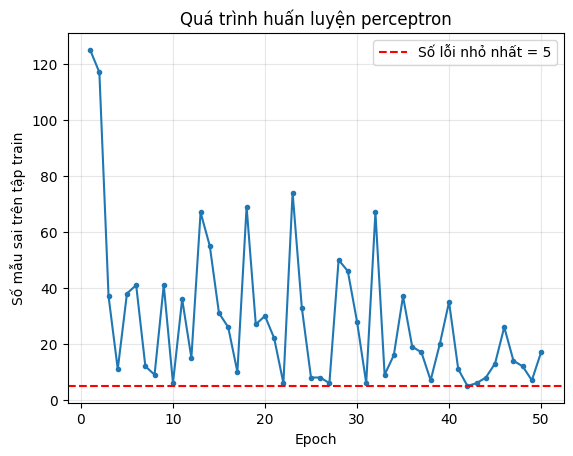

Độ chính xác train của bộ trọng số tốt nhất: 0.979


In [17]:
plt.plot(range(1, len(hist_pla) + 1), hist_pla, marker='.')
plt.axhline(min(hist_pla), color='r', ls='--', label=f'Số lỗi nhỏ nhất = {min(hist_pla)}')
plt.xlabel('Epoch')
plt.ylabel('Số mẫu sai trên tập train')
plt.title('Quá trình huấn luyện perceptron')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print(f'Độ chính xác train của bộ trọng số tốt nhất: {1 - min(hist_pla)/len(y_train):.3f}')

### Trả lời Câu hỏi 5
**Vì sao số lỗi dao động và không giảm về 0?** Dữ liệu được sinh có nhiễu $\varepsilon \sim N(0;\ 0.45)$ nên một số hồ sơ nằm "lấn" sang phía của lớp kia: **không tồn tại siêu phẳng nào tách đúng hết** (dữ liệu không tách được tuyến tính). Thuật toán cập nhật ngay sau mỗi mẫu sai; việc sửa một mẫu nằm sai phía có thể đẩy siêu phẳng làm sai những mẫu khác, nên số lỗi cứ dao động lên xuống giữa các epoch thay vì giảm dần về 0.

**Điều kiện hội tụ chắc chắn:** theo định lý hội tụ perceptron (Rosenblatt, Novikoff), thuật toán dừng sau hữu hạn bước với 0 lỗi **khi và chỉ khi dữ liệu tách được tuyến tính** (và hệ số học η > 0 bất kỳ). Với dữ liệu không tách được tuyến tính như ở đây, phải giới hạn số epoch và dùng kỹ thuật **pocket** để giữ lại bộ trọng số có ít lỗi nhất (5/240, độ chính xác train 0.979).

## Bước 8. Đánh giá trên tập kiểm thử

Mô hình cơ sở (luôn đoán lớp đông nhất): 0.583
Cập nhật tham lam, t cố định:            0.567
Perceptron Learning, học cả ngưỡng:      0.933
              precision    recall  f1-score   support

     Từ chối       0.92      0.92      0.92        25
       Duyệt       0.94      0.94      0.94        35

    accuracy                           0.93        60
   macro avg       0.93      0.93      0.93        60
weighted avg       0.93      0.93      0.93        60



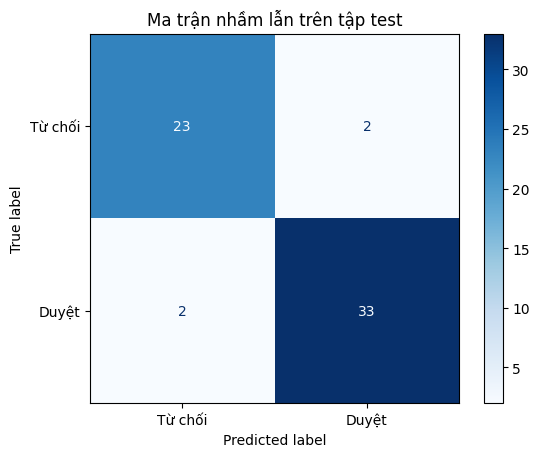

In [18]:
baseline = max(y_test.mean(), 1 - y_test.mean())
y_pred_greedy = step(X_test @ w_greedy - t)
y_pred_pla = predict(add_bias(X_test), w_pla)
print(f'Mô hình cơ sở (luôn đoán lớp đông nhất): {baseline:.3f}')
print(f'Cập nhật tham lam, t cố định:            {accuracy_score(y_test, y_pred_greedy):.3f}')
print(f'Perceptron Learning, học cả ngưỡng:      {accuracy_score(y_test, y_pred_pla):.3f}')
print(classification_report(y_test, y_pred_pla, target_names=['Từ chối', 'Duyệt']))
cm = confusion_matrix(y_test, y_pred_pla)
ConfusionMatrixDisplay(cm, display_labels=['Từ chối', 'Duyệt']).plot(cmap='Blues')
plt.title('Ma trận nhầm lẫn trên tập test')
plt.show()

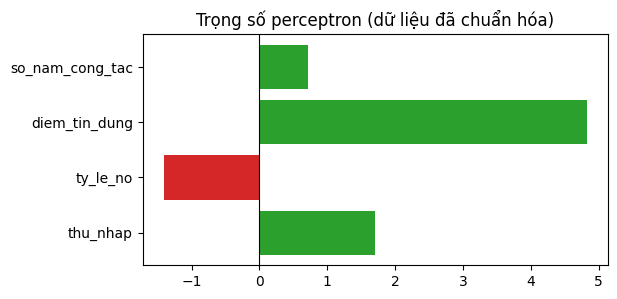

In [19]:
plt.figure(figsize=(6, 3))
colors = ['tab:green' if v > 0 else 'tab:red' for v in w_pla[1:]]
plt.barh(FEATURES, w_pla[1:], color=colors)
plt.axvline(0, color='k', lw=0.8)
plt.title('Trọng số perceptron (dữ liệu đã chuẩn hóa)')
plt.show()

In [20]:
# Bổ sung cho Câu hỏi 7: ảnh hưởng của việc tăng/giảm ngưỡng w0 lên FP, FN
from sklearn.metrics import precision_score, recall_score
for delta in [-0.3, 0.0, 0.3, 0.6]:
    w_tmp = w_pla.copy()
    w_tmp[0] += delta
    p = predict(add_bias(X_test), w_tmp)
    tn, fp, fn, tp = confusion_matrix(y_test, p).ravel()
    print(f'w0 = {w_tmp[0]:.2f}: FP = {fp}, FN = {fn} | precision(Duyệt) = {precision_score(y_test, p):.3f}, '
          f'recall(Duyệt) = {recall_score(y_test, p):.3f}')

w0 = 3.30: FP = 9, FN = 0 | precision(Duyệt) = 0.795, recall(Duyệt) = 1.000
w0 = 3.60: FP = 2, FN = 2 | precision(Duyệt) = 0.943, recall(Duyệt) = 0.943
w0 = 3.90: FP = 0, FN = 14 | precision(Duyệt) = 1.000, recall(Duyệt) = 0.600
w0 = 4.20: FP = 0, FN = 24 | precision(Duyệt) = 1.000, recall(Duyệt) = 0.314


### Trả lời Câu hỏi 6
Mô hình cơ sở (luôn đoán lớp đông nhất là "Duyệt") đã đúng 35/60 = **0.583** mà không cần học gì. Nó là "mức sàn": một mô hình chỉ có ý nghĩa khi **vượt rõ** mức này; nếu không so sánh, ta dễ nhầm tưởng một độ chính xác 0.6 là tốt.

Cách cập nhật tham lam ở Bước 6 đạt 0.696 trên train (> 0.579) nhưng chỉ **0.567 trên test, thấp hơn cả mô hình cơ sở** ⇒ thực chất **không học được quy luật hữu ích**: nó chỉ khớp tạm vài mẫu train với ngưỡng cố định và trọng số `ty_le_no` sai dấu. Perceptron Learning đạt **0.933**, vượt mô hình cơ sở khoảng 35 điểm phần trăm.

### Trả lời Câu hỏi 7
- Trong cho vay, **duyệt nhầm hồ sơ xấu (False Positive)** thường gây thiệt hại lớn hơn: công ty có thể mất cả khoản gốc cho vay; còn từ chối nhầm hồ sơ tốt (False Negative) chỉ mất phần lợi nhuận tiềm năng (lãi) của khoản vay đó.
- Để hạn chế FP cần **tăng ngưỡng $w_0$**: hồ sơ phải đạt $S = \sum w_i x_i - w_0 \ge 0$ khó hơn mới được duyệt (xem ô bổ sung ở trên: khi tăng $w_0$, FP giảm).
- **Đánh đổi:** precision của lớp Duyệt tăng nhưng recall của lớp Duyệt giảm – nhiều hồ sơ tốt bị từ chối hơn (FN tăng), công ty mất khách hàng và doanh thu. Mức ngưỡng là quyết định kinh doanh dựa trên chi phí của từng loại lỗi.

## Bước 9. Thực thi trên hồ sơ mới

In [21]:
new_apps = pd.DataFrame({
    'thu_nhap':        [25.0, 12.0, 40.0],
    'ty_le_no':        [30.0, 55.0, 70.0],
    'diem_tin_dung':   [650, 480, 600],
    'so_nam_cong_tac': [5, 2, 10]},
    index=['HS_moi_1', 'HS_moi_2', 'HS_moi_3'])
X_new = (new_apps[FEATURES] / X_max).values
S_new = add_bias(X_new) @ w_pla
new_apps['S'] = S_new.round(3)
new_apps['Dự đoán'] = np.where(step(S_new) == 1, 'Duyệt', 'Từ chối')
new_apps

,thu_nhap,ty_le_no,diem_tin_dung,so_nam_cong_tac,S,Dự đoán
HS_moi_1,25.0,30.0,650,5,0.823,Duyệt
HS_moi_2,12.0,55.0,480,2,-1.071,Từ chối
HS_moi_3,40.0,70.0,600,10,0.318,Duyệt


**Nhận xét:** HS_moi_1 được duyệt (điểm tín dụng cao, tỷ lệ nợ thấp); HS_moi_2 bị từ chối (điểm tín dụng thấp, tỷ lệ nợ cao). HS_moi_3 được duyệt dù tỷ lệ nợ 70% vì thu nhập cao và thâm niên dài bù lại – đặc điểm của mô hình tuyến tính là các thuộc tính bù trừ cho nhau; thực tế ngân hàng thường thêm luật cứng (ví dụ từ chối nếu tỷ lệ nợ > 60%).

## Bước 10. So sánh với scikit-learn

In [22]:
from sklearn.linear_model import Perceptron
for rs in range(5):
    sk = Perceptron(eta0=0.2, max_iter=1000, random_state=rs)
    sk.fit(X_train, y_train)
    acc = sk.score(X_test, y_test)
    print(f'random_state={rs}: acc test = {acc:.3f} | w = {sk.coef_[0].round(2)} | b = {sk.intercept_[0]:.2f}')

random_state=0: acc test = 0.933 | w = [ 1.19 -0.94  2.9   0.56] | b = -2.20
random_state=1: acc test = 0.967 | w = [ 1.11 -0.88  3.23  0.49] | b = -2.40
random_state=2: acc test = 0.933 | w = [ 0.99 -0.88  3.08  0.47] | b = -2.20
random_state=3: acc test = 0.917 | w = [ 1.32 -0.93  3.37  0.46] | b = -2.60
random_state=4: acc test = 0.933 | w = [ 1.11 -0.91  3.    0.37] | b = -2.20


In [23]:
# Bổ sung cho Câu hỏi 8: chia mỗi bộ trọng số cho ngưỡng của nó
print('Bước 7  : w / w0  =', (w_pla[1:] / w_pla[0]).round(2))
for rs in range(5):
    sk = Perceptron(eta0=0.2, max_iter=1000, random_state=rs).fit(X_train, y_train)
    print(f'sklearn rs={rs}: w / |b| =', (sk.coef_[0] / abs(sk.intercept_[0])).round(2))

Bước 7  : w / w0  = [ 0.47 -0.39  1.34  0.2 ]
sklearn rs=0: w / |b| = [ 0.54 -0.43  1.32  0.26]
sklearn rs=1: w / |b| = [ 0.46 -0.37  1.35  0.2 ]
sklearn rs=2: w / |b| = [ 0.45 -0.4   1.4   0.21]
sklearn rs=3: w / |b| = [ 0.51 -0.36  1.29  0.18]
sklearn rs=4: w / |b| = [ 0.5  -0.41  1.36  0.17]


### Trả lời Câu hỏi 8
Hàm bước $H$ chỉ phụ thuộc vào **dấu** của $S = \mathbf{w}\cdot\mathbf{x} - w_0$. Nhân toàn bộ $(\mathbf{w}, w_0)$ với một số dương $c$ bất kỳ thì $cS$ cùng dấu với $S$ ⇒ dự đoán không đổi. Siêu phẳng quyết định $\mathbf{w}\cdot\mathbf{x} = w_0$ chỉ phụ thuộc vào **tỉ lệ** giữa các trọng số, không phụ thuộc độ lớn.

Chia cho ngưỡng (xem ô bổ sung ở trên):
- Bước 7: $\mathbf{w}/w_0 \approx (0.47;\ -0.39;\ 1.34;\ 0.20)$.
- sklearn (random_state = 0): $\mathbf{w}/|b| \approx (0.54;\ -0.43;\ 1.32;\ 0.25)$.

Hai bộ tỉ lệ gần như trùng nhau ⇒ hai siêu phẳng gần như trùng nhau ⇒ độ chính xác tương đương. Khác biệt nhỏ còn lại do sklearn khởi tạo trọng số bằng 0, dùng thứ tự xáo trộn và tiêu chí dừng khác, và trả về trọng số của epoch cuối (không có pocket), nên kết quả thay đổi nhẹ theo `random_state`. Lưu ý quy ước dấu: sklearn viết $S = \mathbf{w}\cdot\mathbf{x} + b$ nên $b \leftrightarrow -w_0$.

---
# 7. BÀI TẬP VỀ NHÀ

### Bài 1. Thay η ∈ {0.01; 0.05; 0.5; 1.0} ở Bước 7

η = 0.01 : lỗi train nhỏ nhất =   7 | lỗi epoch cuối =  26 | acc test = 0.933 | w/w0 = [ 0.46 -0.33  1.3   0.21]
η = 0.05 : lỗi train nhỏ nhất =   5 | lỗi epoch cuối =  36 | acc test = 0.933 | w/w0 = [ 0.47 -0.39  1.34  0.21]
η = 0.5  : lỗi train nhỏ nhất =   5 | lỗi epoch cuối =  19 | acc test = 0.933 | w/w0 = [ 0.5  -0.38  1.33  0.19]
η = 1.0  : lỗi train nhỏ nhất =   5 | lỗi epoch cuối =  30 | acc test = 0.933 | w/w0 = [ 0.49 -0.41  1.35  0.19]


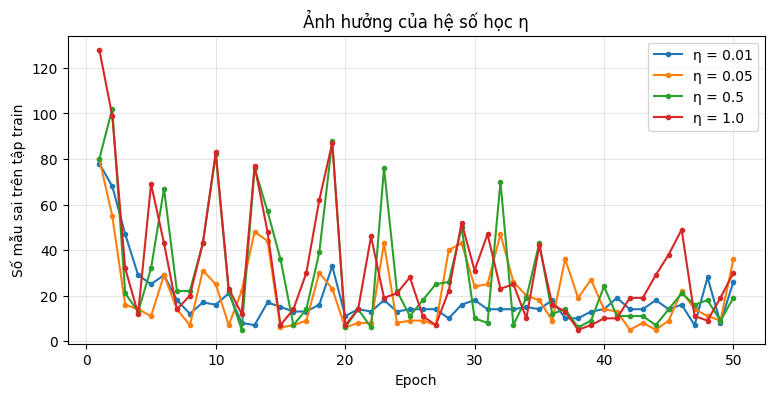

In [24]:
plt.figure(figsize=(9, 4))
for e in [0.01, 0.05, 0.5, 1.0]:
    w_e, h_e = perceptron_train(X_train, y_train, w_init, eta=e, epochs=50)
    acc_te = accuracy_score(y_test, predict(add_bias(X_test), w_e))
    print(f'η = {e:<5}: lỗi train nhỏ nhất = {min(h_e):3d} | lỗi epoch cuối = {h_e[-1]:3d} | acc test = {acc_te:.3f} '
          f'| w/w0 = {(w_e[1:] / w_e[0]).round(2)}')
    plt.plot(range(1, len(h_e) + 1), h_e, marker='.', label=f'η = {e}')
plt.xlabel('Epoch')
plt.ylabel('Số mẫu sai trên tập train')
plt.title('Ảnh hưởng của hệ số học η')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Nhận xét Bài 1:** - **η nhỏ (0.01):** trọng số thay đổi chậm so với giá trị khởi tạo nên số lỗi giảm từ từ trong vài epoch đầu (78 → 68 → 47 → 29 → 25) và dao động ít nhất (độ lệch chuẩn số lỗi theo epoch ≈ 13); lỗi nhỏ nhất đạt 7/240.
- **η lớn (0.5; 1.0):** mỗi lần sửa một mẫu làm siêu phẳng "nhảy" mạnh nên đường số lỗi dao động rất lớn (có epoch lên tới 60 – 130 lỗi, độ lệch chuẩn ≈ 25), trọng số có độ lớn lớn hơn nhiều (‖w‖ ≈ 9 với η = 0.5 và ≈ 30 với η = 1.0).
- Tuy vậy, với η ≥ 0.05, **lỗi nhỏ nhất đều là 5/240** và **độ chính xác test đều là 0.933**; tỉ lệ $\mathbf{w}/w_0$ gần như như nhau (≈ 0.47; −0.39; 1.34; 0.20). Lý do: hàm bước chỉ phụ thuộc dấu của $S$, nên khi trọng số đã lớn hơn nhiều so với giá trị khởi tạo, nhân η với một hằng số chỉ làm "phóng to" toàn bộ w mà không đổi siêu phẳng. η chỉ thực sự có ảnh hưởng thông qua **tỉ lệ giữa bước cập nhật và trọng số khởi tạo**.
- Với dữ liệu không tách được tuyến tính, số lỗi của epoch cuối luôn cao (19 – 36) với mọi η ⇒ kỹ thuật pocket là bắt buộc. η quá nhỏ cần nhiều epoch hơn; η vừa phải (0.05 – 0.2) là lựa chọn hợp lý.

### Bài 2. Khởi tạo trọng số ngẫu nhiên với 5 seed khác nhau
Trọng số khởi tạo (kể cả $w_0$) lấy ngẫu nhiên đều trong $[0, 1]$; giữ η = 0.2, 50 epoch, thứ tự duyệt mẫu như Bước 7.

In [25]:
rows = []
for sd in [1, 2, 3, 4, 5]:
    w_rand = np.random.default_rng(sd).uniform(0, 1, 5)
    w_s, h_s = perceptron_train(X_train, y_train, w_rand, eta=0.2, epochs=50)
    rows.append({'seed': sd, 'w_init': w_rand.round(2), 'lỗi train nhỏ nhất': min(h_s),
                 'acc train': 1 - min(h_s) / len(y_train),
                 'acc test': accuracy_score(y_test, predict(add_bias(X_test), w_s)),
                 'w/w0': (w_s[1:] / w_s[0]).round(2)})
res2 = pd.DataFrame(rows)
display(res2)
print(f"acc test: trung bình = {res2['acc test'].mean():.3f}, độ lệch chuẩn = {res2['acc test'].std():.3f}, "
      f"min = {res2['acc test'].min():.3f}, max = {res2['acc test'].max():.3f}")

,seed,w_init,lỗi train nhỏ nhất,acc train,acc test,w/w0
0,1,"[0.51, 0.95, 0.14, 0.95, 0.31]",5,0.979,0.933,"[0.45, -0.38, 1.35, 0.18]"
1,2,"[0.26, 0.3, 0.81, 0.09, 0.6]",5,0.979,0.933,"[0.49, -0.36, 1.33, 0.17]"
2,3,"[0.09, 0.24, 0.8, 0.58, 0.09]",5,0.979,0.933,"[0.52, -0.41, 1.34, 0.18]"
3,4,"[0.94, 0.51, 0.98, 0.08, 0.61]",5,0.979,0.933,"[0.47, -0.38, 1.34, 0.17]"
4,5,"[0.81, 0.81, 0.52, 0.29, 0.05]",5,0.979,0.933,"[0.46, -0.39, 1.34, 0.2]"


acc test: trung bình = 0.933, độ lệch chuẩn = 0.000, min = 0.933, max = 0.933


**Nhận xét Bài 2:** - Cả 5 seed đều cho **lỗi train nhỏ nhất 5/240 (0.979)** và **độ chính xác test 0.933** (độ lệch chuẩn = 0), tỉ lệ $\mathbf{w}/w_0$ gần như trùng nhau (≈ 0.45 – 0.52; −0.36 – −0.41; 1.33 – 1.35; 0.17 – 0.20).
- Lý do: trọng số khởi tạo trong [0, 1] là rất nhỏ so với trọng số cuối (‖w‖ ≈ 6), sau vài epoch ảnh hưởng của điểm xuất phát gần như bị xóa; dữ liệu lại gần tách được tuyến tính nên chỉ có một vùng siêu phẳng tốt. Kết luận: với perceptron + pocket trên bộ dữ liệu này, **kết quả ổn định, không nhạy với khởi tạo**. (Khác biệt nhỏ giữa các seed chỉ nằm ở các chữ số thập phân của trọng số.)

### Bài 3. Bỏ thuộc tính `diem_tin_dung` rồi huấn luyện lại

In [26]:
F3 = ['thu_nhap', 'ty_le_no', 'so_nam_cong_tac']
X3_max = train_df[F3].max()
X3_train = (train_df[F3] / X3_max).values
X3_test = (test_df[F3] / X3_max).values
w3, h3 = perceptron_train(X3_train, y_train, [0.6, 0.1, 0.2, 0.4], eta=0.2, epochs=50)
acc3_tr = 1 - min(h3) / len(y_train)
acc3_te = accuracy_score(y_test, predict(add_bias(X3_test), w3))
acc_full = accuracy_score(y_test, y_pred_pla)
print(pd.Series(w3, index=['w0'] + F3).round(3))
print(f'Đủ 4 thuộc tính : acc train = {1 - min(hist_pla)/len(y_train):.3f} | acc test = {acc_full:.3f}')
print(f'Bỏ diem_tin_dung: acc train = {acc3_tr:.3f} | acc test = {acc3_te:.3f}')
print(f'Độ chính xác test giảm {acc_full - acc3_te:.3f} ({(acc_full - acc3_te)*100:.1f} điểm %), '
      f'mô hình cơ sở = {baseline:.3f}')

w0                -0.000
thu_nhap           0.573
ty_le_no          -0.383
so_nam_cong_tac    0.282
dtype: float64
Đủ 4 thuộc tính : acc train = 0.979 | acc test = 0.933
Bỏ diem_tin_dung: acc train = 0.688 | acc test = 0.767
Độ chính xác test giảm 0.167 (16.7 điểm %), mô hình cơ sở = 0.583


**Nhận xét Bài 3:** - Bỏ `diem_tin_dung`, độ chính xác **train giảm từ 0.979 xuống 0.688**, **test giảm từ 0.933 xuống 0.767 (≈ 16.7 điểm %)**, chỉ còn hơn mô hình cơ sở (0.583) khoảng 18 điểm %.
- Đây là thuộc tính quan trọng nhất: tương quan với nhãn +0.65 (lớn nhất), có trọng số lớn nhất ở Bước 7 (4.823), và trong quy luật sinh dữ liệu nó đóng góp nhiều nhất vào điểm thẩm định ẩn $z$ (0.026 × độ lệch chuẩn 75 ≈ 1.95, lớn hơn các thuộc tính khác). Ba thuộc tính còn lại vẫn giữ dấu đúng (thu nhập +, tỷ lệ nợ −, thâm niên +) nhưng không đủ thông tin để phân biệt hai lớp: phần lớn biến thiên của nhãn giờ trở thành "nhiễu" đối với mô hình nên dữ liệu không còn gần tách được tuyến tính.

### Bài 4. Chuẩn hóa Min-Max $x' = (x - \min)/(\max - \min)$ (min, max lấy trên tập train)

Min train: [  5.   5. 343.   0.] | Max train: [ 80.  85. 742.  22.]
w0                 1.800
thu_nhap           2.150
ty_le_no          -1.708
diem_tin_dung      3.428
so_nam_cong_tac    0.900
dtype: float64
Chuẩn hóa theo Max : lỗi train nhỏ nhất = 5 | acc test = 0.933
Chuẩn hóa Min-Max  : lỗi train nhỏ nhất = 5 | acc test = 0.933


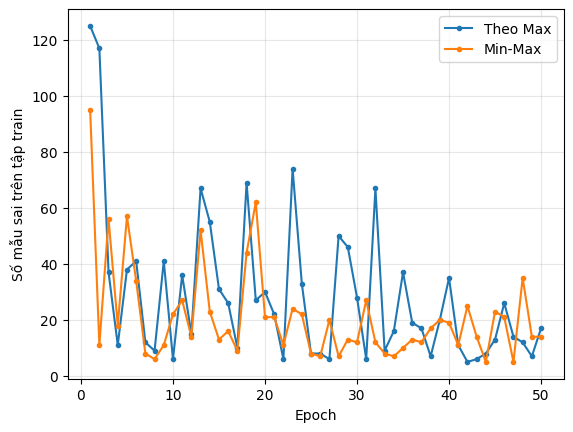

In [27]:
X_min = train_df[FEATURES].min()
rng_ = X_max - X_min
Xm_train = ((train_df[FEATURES] - X_min) / rng_).values
Xm_test = ((test_df[FEATURES] - X_min) / rng_).values
print('Min train:', X_min.values, '| Max train:', X_max.values)
w_mm, h_mm = perceptron_train(Xm_train, y_train, w_init, eta=0.2, epochs=50)
acc_mm = accuracy_score(y_test, predict(add_bias(Xm_test), w_mm))
print(pd.Series(w_mm, index=['w0'] + FEATURES).round(3))
print(f'Chuẩn hóa theo Max : lỗi train nhỏ nhất = {min(hist_pla)} | acc test = {acc_full:.3f}')
print(f'Chuẩn hóa Min-Max  : lỗi train nhỏ nhất = {min(h_mm)} | acc test = {acc_mm:.3f}')
plt.plot(range(1, len(hist_pla) + 1), hist_pla, marker='.', label='Theo Max')
plt.plot(range(1, len(h_mm) + 1), h_mm, marker='.', label='Min-Max')
plt.xlabel('Epoch')
plt.ylabel('Số mẫu sai trên tập train')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Nhận xét Bài 4:** - Cả hai cách chuẩn hóa đều cho **lỗi train nhỏ nhất 5/240 và độ chính xác test 0.933**.
- Lý do: Min-Max chỉ là một phép biến đổi tuyến tính (co giãn + tịnh tiến) của từng thuộc tính, phần tịnh tiến được "hấp thụ" vào ngưỡng $w_0$. Vì vậy tập các siêu phẳng mà perceptron biểu diễn được là như nhau; chỉ giá trị trọng số thay đổi (Min-Max: $w_0$ = 1.800, w = (2.150; −1.708; 3.428; 0.900)).
- Ưu điểm của Min-Max: dữ liệu trải đều trên cả đoạn [0, 1] (theo Max thì `diem_tin_dung` chỉ nằm trong 0.46 – 1.0), các thuộc tính có miền giá trị đồng đều hơn nên tốc độ học của các trọng số cân bằng hơn và ngưỡng nhỏ hơn. Nhược điểm: giá trị test có thể < 0 hoặc > 1 nếu nằm ngoài miền của train, và nhạy với ngoại lai.

### Bài 5. Tính tay một lần cập nhật trọng số cho hồ sơ đầu tiên của tập train
Hồ sơ đầu tiên của tập train là **HS110**: thu_nhap = 32.0, ty_le_no = 23.6, diem_tin_dung = 677, so_nam_cong_tac = 8, **T = 1**.

**1. Chuẩn hóa theo Max** (Max = 80; 85; 742; 22) và thêm $x_0 = -1$:

$$\mathbf{x} = \left(-1;\ \tfrac{32}{80};\ \tfrac{23.6}{85};\ \tfrac{677}{742};\ \tfrac{8}{22}\right) = (-1;\ 0.4000;\ 0.2776;\ 0.9124;\ 0.3636)$$

**2. Trọng số khởi tạo** (như Bước 7): $\mathbf{w} = (w_0;\ w_1;\ w_2;\ w_3;\ w_4) = (0.6;\ 0.1;\ 0.2;\ 0.3;\ 0.4)$, η = 0.2.

**3. Tính S và O:**

$$S = 0.6(-1) + 0.1(0.4000) + 0.2(0.2776) + 0.3(0.9124) + 0.4(0.3636)$$
$$= -0.6 + 0.0400 + 0.0555 + 0.2737 + 0.1455 = -0.0853$$

$S < 0 \Rightarrow O = H(S) = 0$, trong khi $T = 1 \Rightarrow T - O = 1$ (dự đoán sai).

**4. Cập nhật** $\Delta w_i = \eta \cdot x_i \cdot (T - O) = 0.2 \cdot x_i \cdot 1$:

| | $w_0$ | $w_1$ (thu_nhap) | $w_2$ (ty_le_no) | $w_3$ (diem_tin_dung) | $w_4$ (so_nam) |
|---|---|---|---|---|---|
| $x_i$ | −1 | 0.4000 | 0.2776 | 0.9124 | 0.3636 |
| $\Delta w_i$ | −0.2000 | 0.0800 | 0.0555 | 0.1825 | 0.0727 |
| $w_i$ mới | **0.4000** | **0.1800** | **0.2555** | **0.4825** | **0.4727** |

Nhận xét: vì T − O = +1, mọi trọng số của thuộc tính tăng (tỉ lệ với $x_i$, nên `diem_tin_dung` tăng nhiều nhất) còn ngưỡng $w_0$ giảm 0.2 ⇒ hồ sơ này dễ được duyệt hơn ở lần sau. Kiểm tra lại: $S_{mới} = -0.4 + 0.072 + 0.0709 + 0.4402 + 0.1719 = 0.355 \ge 0 \Rightarrow O = 1$ (đúng). Ô code dưới đây xác nhận kết quả.

In [28]:
# Kiểm tra bằng code
x1 = add_bias(X_train[:1])[0]
w_cur = np.array(w_init, dtype=float)
S1 = x1 @ w_cur
O1 = step(S1)
T1 = y_train[0]
dw = 0.2 * x1 * (T1 - O1)
print('Hồ sơ:', train_df.iloc[0]['ma_ho_so'], '| x (có x0 = -1) =', x1.round(4))
print(f'S = {S1:.4f} -> O = {O1} | T = {T1} | T - O = {T1 - O1}')
print('Δw =', dw.round(4))
print('w mới =', (w_cur + dw).round(4))

Hồ sơ: HS110 | x (có x0 = -1) = [-1.     0.4    0.278  0.912  0.364]
S = -0.0853 -> O = 0 | T = 1 | T - O = 1
Δw = [-0.2    0.08   0.056  0.182  0.073]
w mới = [0.4   0.18  0.256 0.482 0.473]


---
## Bảng tổng hợp kết quả
| Phương pháp | Độ chính xác train | Độ chính xác test |
|---|---|---|
| Mô hình cơ sở (luôn đoán "Duyệt") | 0.579 | 0.583 |
| Khởi tạo w = (0.1; 0.2; 0.3; 0.4), t = 0.6, chưa học | 0.450 | |
| Chọn hướng giảm sai số nhiều nhất, t cố định (Bước 6) | 0.696 | 0.567 |
| Perceptron Learning, bias học được, pocket (Bước 7) | 0.979 | 0.933 |
| sklearn Perceptron (5 giá trị random_state) | | 0.917 – 0.967 |